<a href="https://colab.research.google.com/github/VijaiyWorld/ML_AI/blob/main/Txt-image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import torch
from diffusers import StableDiffusionXLPipeline, DPMSolverSinglestepScheduler

# Load model.
pipe = StableDiffusionXLPipeline.from_pretrained("sd-community/sdxl-flash", torch_dtype=torch.float16).to("cuda")



The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

unet/config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/5.14G [00:00<?, ?B/s]

vae/config.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [2]:
# Ensure sampler uses "trailing" timesteps.
pipe.scheduler = DPMSolverSinglestepScheduler.from_config(pipe.scheduler.config, timestep_spacing="trailing")

In [ ]:
##  timestep spacing : leading , linespae , trailing
##  num inference steps: Denoising step

In [5]:
Imgval = """create a HD wallpaper with BMW car"""

  0%|          | 0/10 [00:00<?, ?it/s]

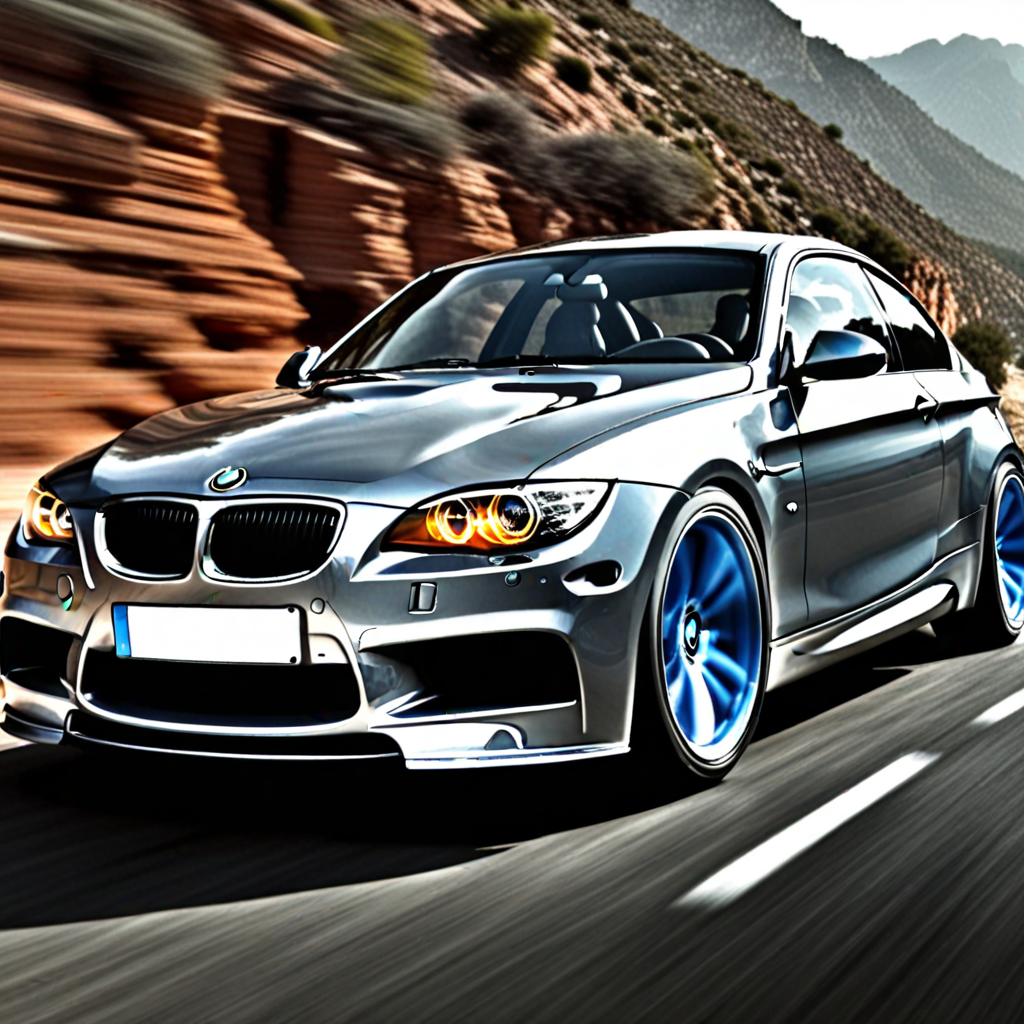

In [6]:

# Image generation.
pipe(Imgval, num_inference_steps=10, guidance_scale=8).images[0]

### Text to Audio

In [ ]:
from transformers import pipeline
import scipy

synthesiser = pipeline("text-to-audio", "facebook/musicgen-small")


In [ ]:
music = synthesiser("morning rington", forward_params={"do_sample": True})

scipy.io.wavfile.write("ringtone.wav", rate=music["sampling_rate"], data=music["audio"])